# 📊 Análisis de Medidas de Tendencia Central y Dispersión

**Reporte estadístico aplicado**

---

**Autor:**  
ChicoPython 

**Fecha:**  
{{ 31/01/2026 }}

**Herramientas:**  
Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook  

---

Este reporte presenta un análisis exploratorio de datos enfocado en las **medidas de tendencia central** y **medidas de dispersión**, utilizando una base de datos simulada de empleados de una empresa.


## 1. Introducción

En el análisis estadístico de datos, no basta con conocer un valor promedio.  
También es fundamental comprender **cómo se distribuyen los datos** y **qué tan dispersos están**.

Las **medidas de tendencia central** (media, mediana y moda) permiten identificar valores representativos, mientras que las **medidas de dispersión** (rango, varianza y desviación estándar) ayudan a interpretar la variabilidad de los datos.

En este reporte se analizan estas medidas utilizando información salarial simulada de una empresa con una estructura jerárquica realista.

## 2. Carga y descripción de los datos

Se utiliza una base de datos con aproximadamente **5.000 empleados**, que incluye información sobre:

- Cargo
- Edad
- Salario
- Horas trabajadas
- Nivel educativo

A continuación, se importan los datos y se revisa su estructura general.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Cargar la base de datos
df = pd.read_csv("base_datos_empresa_practica_estructura_realista.csv")

# Vista general
df.head()

,ID_Empleado,Cargo,Edad,Salario,Horas_trabajadas,Nivel_Educativo
0,E00001,CEO,56,200000000,166,Maestría
1,E00002,Director,58,25317789,188,Maestría
2,E00003,Director,47,24735746,214,Maestría
3,E00004,Director,58,28853155,193,Maestría
4,E00005,Director,61,27909579,198,Maestría


## 3. Estructura organizacional

Antes de analizar los salarios, es importante entender la estructura de cargos dentro de la empresa.

Una organización real suele presentar:
- Pocos cargos altos
- Muchos cargos operativos

La siguiente tabla muestra la cantidad de empleados por cargo.

In [3]:
# Contar número de personas por cargo
conteo_cargos = (
    df["Cargo"]
    .value_counts()
    .reset_index()
)

# Renombrar columnas
conteo_cargos.columns = ["Cargo", "Cantidad de empleados"]

# Mostrar tabla
print(conteo_cargos)

                      Cargo  Cantidad de empleados
0                  Analista                   1200
1  Asistente Administrativo                    900
2        Auxiliar Operativo                    700
3           Analista Senior                    500
4                 Seguridad                    389
5               Coordinador                    200
6              Jefe de Área                     80
7                   Gerente                     25
8                  Director                      5
9                       CEO                      1


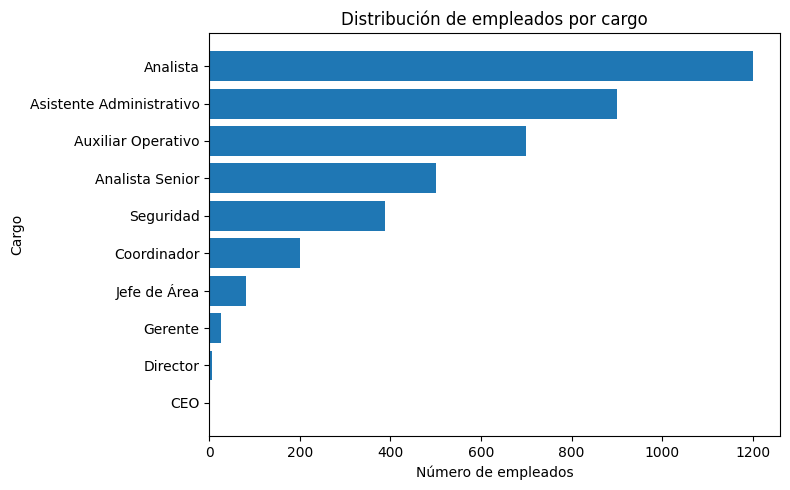

In [4]:
plt.figure(figsize=(8, 5))
plt.barh(conteo_cargos["Cargo"], conteo_cargos["Cantidad de empleados"])
plt.xlabel("Número de empleados")
plt.ylabel("Cargo")
plt.title("Distribución de empleados por cargo")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Medidas de tendencia central del salario

Las medidas de tendencia central permiten resumir el salario típico de los empleados:

- **Media:** promedio aritmético
- **Mediana:** valor central
- **Moda:** valor más frecuente

Estas medidas pueden diferir significativamente cuando existen valores extremos.

In [5]:
media_salario = df["Salario"].mean()
mediana_salario = df["Salario"].median()
moda_salario = df["Salario"].mode()[0]

print(f"Media del salario: {media_salario:,.0f}")
print(f"Mediana del salario: {mediana_salario:,.0f}")
print(f"Moda del salario: {moda_salario:,.0f}")

Media del salario: 4,056,171
Mediana del salario: 3,112,254
Moda del salario: 1,300,000


## 5. Distribución del salario

Para visualizar la forma en que se distribuyen los salarios, se utilizan gráficos de distribución.

Estos gráficos permiten detectar:
- Asimetría
- Concentración de valores
- Presencia de valores extremos

                      Cargo  Media_Salarial  Mediana_Salarial  Empleados
4                       CEO     200000000.0       200000000.0          1
6                  Director      27414356.0        27909579.0          5
7                   Gerente      16752279.0        17101435.0         25
8              Jefe de Área      11695350.0        11756870.0         80
5               Coordinador       9431218.0         9329576.0        200
1           Analista Senior       7625262.0         7632408.0        500
0                  Analista       4289405.0         4275508.0       1200
2  Asistente Administrativo       2298611.0         2295194.0        900
9                 Seguridad       1526885.0         1523934.0        389
3        Auxiliar Operativo       1463300.0         1451349.0        700


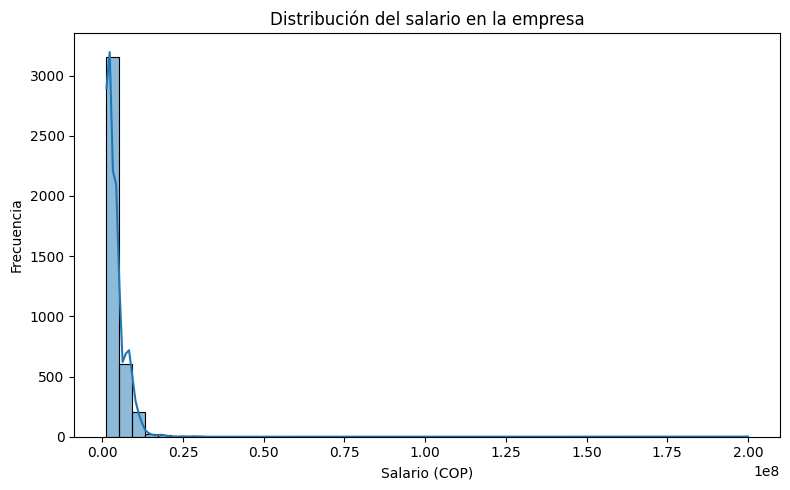

In [6]:
# Calcular media y mediana por cargo
tabla_salarios = (
    df
    .groupby("Cargo")["Salario"]
    .agg(
        Media_Salarial="mean",
        Mediana_Salarial="median",
        Empleados="count"
    )
    .reset_index()
)

# Redondear valores para mejor lectura
tabla_salarios["Media_Salarial"] = tabla_salarios["Media_Salarial"].round(0)
tabla_salarios["Mediana_Salarial"] = tabla_salarios["Mediana_Salarial"].round(0)

# Ordenar por jerarquía salarial
tabla_salarios = tabla_salarios.sort_values(
    by="Media_Salarial",
    ascending=False
)

# Mostrar tabla
print(tabla_salarios)

plt.figure(figsize=(8, 5))
sns.histplot(df["Salario"], bins=50, kde=True)
plt.xlabel("Salario (COP)")
plt.ylabel("Frecuencia")
plt.title("Distribución del salario en la empresa")
plt.tight_layout()
plt.show()

## 6. Análisis sin cargos altos

Los cargos directivos suelen tener salarios muy elevados y baja frecuencia, lo que puede distorsionar el análisis.

Por esta razón, se repite el análisis excluyendo los cargos más altos, con el fin de observar el comportamiento salarial del resto de la empresa.


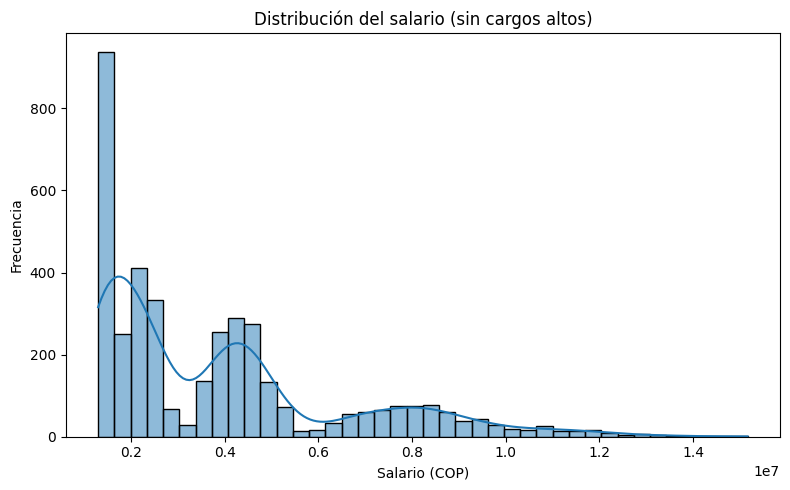

In [7]:
# Definir cargos altos a excluir
cargos_altos = ["CEO", "Director", "Gerente"]

# Filtrar base sin cargos altos
df_sin_cargos_altos = df[~df["Cargo"].isin(cargos_altos)]

# Histograma
plt.figure(figsize=(8, 5))
sns.histplot(
    df_sin_cargos_altos["Salario"],
    bins=40,
    kde=True
)

plt.xlabel("Salario (COP)")
plt.ylabel("Frecuencia")
plt.title("Distribución del salario (sin cargos altos)")
plt.tight_layout()
plt.show()

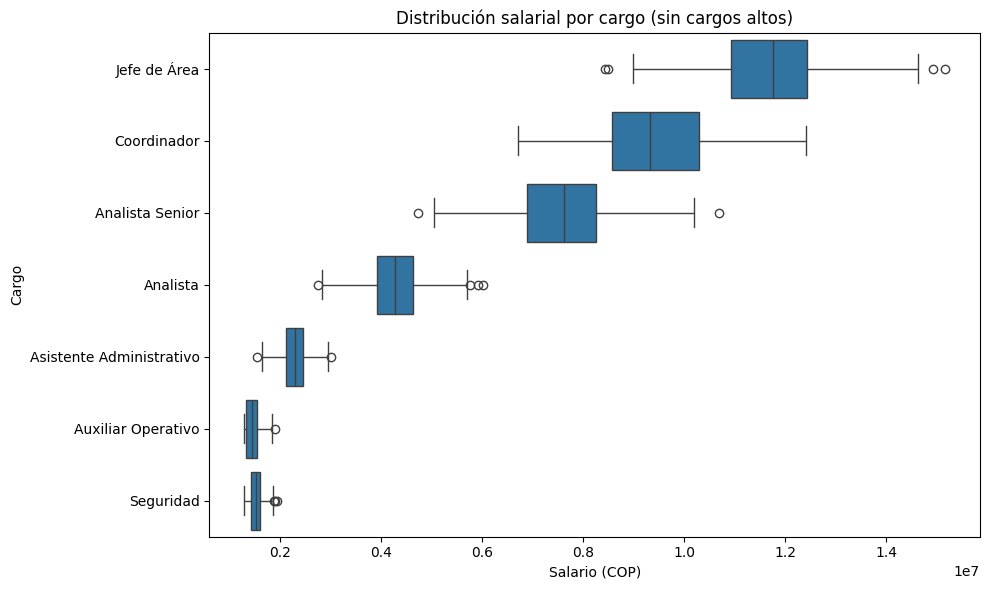

In [8]:
# Excluir cargos altos
cargos_altos = ["CEO", "Director", "Gerente"]
df_sin_cargos_altos = df[~df["Cargo"].isin(cargos_altos)]

# Boxplot por cargo
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_sin_cargos_altos,
    x="Salario",
    y="Cargo"
)

plt.xlabel("Salario (COP)")
plt.ylabel("Cargo")
plt.title("Distribución salarial por cargo (sin cargos altos)")
plt.tight_layout()
plt.show()

## 8. Medidas de dispersión

Las medidas de dispersión permiten cuantificar la variabilidad de los salarios.

En particular:
- **Rango:** diferencia entre el salario máximo y mínimo
- **Varianza:** dispersión promedio al cuadrado respecto a la media
- **Desviación estándar:** dispersión promedio en las mismas unidades del salario

Estas medidas complementan la información proporcionada por la media y la mediana.


In [10]:
salarios = df_sin_cargos_altos["Salario"]
rango = salarios.max() - salarios.min()

print(f"Rango salarial: {rango:,.0f}")

varianza_muestral = salarios.var(ddof=1)
print(f"Varianza muestral: {varianza_muestral:,.2f}")

std_muestral = salarios.std(ddof=1)
print(f"Desviación estándar muestral: {std_muestral:,.2f}")

Rango salarial: 13,859,316
Varianza muestral: 7,067,069,061,723.18
Desviación estándar muestral: 2,658,395.96


## 9. Conclusiones

Del análisis realizado se concluye que:

- El salario promedio puede verse afectado por valores extremos.
- La mediana es una medida más robusta en presencia de outliers.
- La dispersión salarial es considerable incluso dentro de niveles educativos similares.
- El uso combinado de medidas numéricas y gráficos es esencial para una correcta interpretación de los datos.

Este tipo de análisis es fundamental para estudios laborales, económicos y organizacionales.

## Anexo: Notas metodológicas

- Los datos utilizados son simulados, pero siguen una estructura realista.
- El análisis se realizó en Python utilizando librerías estándar de análisis de datos.
- Los resultados tienen fines pedagógicos y demostrativos.
